###### 2/17/2026
## Initial SARMIA model for Climate Data


#### Variable and Parameters Names
 - Climate = the original data set (146 observations with 19 parameters)
 - months = Monthly climate data
 - J.D = Jan - Dec (Yearly temp)
 - N.D = Dec - Nov (Meteorological Year)
 - DJF = Dec, Jan, Feb
 - MAM = Mar, Apr, May
 - JJA = June, July, Aug
 - SON = Sep, Oct, Nov




In [15]:
# Libraries to for use
# pmdarima = "py" + "arima" and seems to be a strong choice for Python?
## documentation: https://alkaline-ml.com/pmdarima/modules/classes.html
import pandas as pd
import numpy as np
import seaborn as sns
import json
from pmdarima.arima import ADFTest, ARIMA, AutoARIMA
from pmdarima.utils import as_series, acf, diff, pacf, plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
#from statmodels import 
#from pmdarima.fit import summary, predict
plt.style.use('seaborn-v0_8-whitegrid')

#### Initial Loading and processing of data:

In [24]:
Climate = pd.read_csv("data/GLB.Ts+dSST.csv", skiprows=1, na_values="***")
Climate.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-0.10,-0.17,-0.11,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-0.18,-0.18,NaN,NaN,-0.13,-0.17,-0.21
1,1881,-0.21,-0.15,0.02,0.04,0.05,-0.20,-0.01,-0.04,-0.16,-0.22,-0.19,-0.08,-0.10,-0.10,-0.18,0.04,-0.08,-0.19
2,1882,0.15,0.13,0.04,-0.18,-0.15,-0.24,-0.17,-0.08,-0.15,-0.24,-0.17,-0.37,-0.12,-0.09,0.07,-0.10,-0.16,-0.19
3,1883,-0.30,-0.37,-0.13,-0.19,-0.18,-0.07,-0.08,-0.14,-0.22,-0.11,-0.25,-0.12,-0.18,-0.20,-0.35,-0.17,-0.10,-0.19
4,1884,-0.14,-0.09,-0.37,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.31,-0.29


### Exploritory Analysis of the data

In [27]:
North = pd.read_csv("Data/NH.Ts+dSST.csv", skiprows=1, na_values="***")
South = pd.read_csv("Data/SH.Ts+dSST.csv", skiprows=1, na_values="***")

## Cleaning data
labelsDJ = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov']
labelsDJF = ['Jan', 'Feb']

Climate.at[0,"D-N"] = Climate.loc[0,labelsDJ].mean().round(2)
Climate.at[0,"DJF"] =  Climate.loc[0,labelsDJF].mean()

North.at[0,"D-N"] = North.loc[0,labelsDJ].mean().round(2)
North.at[0,"DJF"] =  North.loc[0,labelsDJF].mean()

South.at[0,"D-N"] = South.loc[0,labelsDJ].mean().round(2)
South.at[0,"DJF"] =  South.loc[0,labelsDJF].mean()

#Climate.shape
#South.shape
North.shape
print((Climate["J-D"]).mean() + 47)
len(Climate)
print(max(North["J-D"]))
print(max(South["J-D"]))

47.08027397260274
1.65
0.91


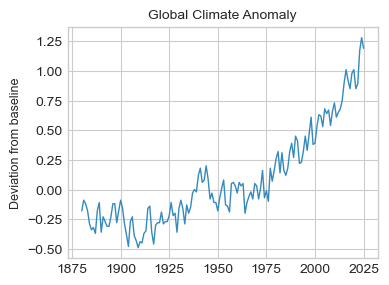

In [18]:
## Creating a general time series plots
plt.figure(figsize = (4,3))
plt.plot(Climate['Year'],Climate["J-D"], linewidth = 1, label = "Original", color = "#348ABD")
#plt.plot(Climate['Year'],Climate["J-D"], label = "Original")
plt.title("Global Climate Anomaly", fontsize=10)
plt.ylabel("Deviation from baseline", fontsize=9)
plt.show()

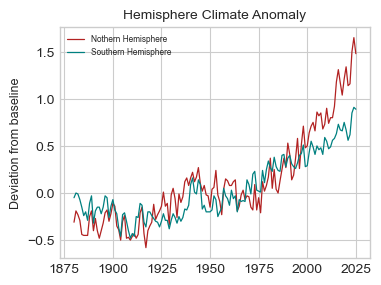

In [19]:
## Northern and Southern plots. 
plt.figure(figsize = (4,3))
#plt.plot(Climate['Year'],Climate["J-D"], linewidth = 1, label = "Original")
plt.plot(North['Year'],North["J-D"], linewidth = .9, label = "Nothern Hemisphere", color = "firebrick")
plt.plot(South['Year'],South["J-D"], linewidth = .9, label = "Southern Hemisphere", color = "teal")
plt.title("Hemisphere Climate Anomaly", fontsize=10)
plt.ylabel("Deviation from baseline", fontsize= 9)
plt.legend(fontsize=6)
plt.show()

#### Initial SARIMA fitting
SARIMA models use a mix of AutoCorrelation and Moving Averages with integrated differencing. The first step is to test for stationarity and coerce the data to stationarity if needed. Then we use ACF and PACF (autocorrelation functions and partial autocorrelation functions) to decide the lag orders for the MA, AR, and seasonal MA and AR. 

In [20]:
#Pulling the J-D data
year = as_series(Climate["J-D"])
year.head()

# Pull J-D and force numeric (*** -> NaN)
year = pd.to_numeric(Climate["J-D"], errors="coerce").dropna()

adf_test = ADFTest(alpha=0.05)
p_val, should_diff = adf_test.should_diff(year)

print(f"N used: {len(year)}")
print(f"P-value: {p_val:.6g}, Should difference: {should_diff}")

## Fuller Dickey test for differencing
adf_test = ADFTest(alpha=0.05)
p_val, should_diff = adf_test.should_diff(year)
print(f"P-value: {p_val}, Should difference: {should_diff}")


N used: 146
P-value: 0.975569, Should difference: True
P-value: 0.9755688492544883, Should difference: True


In [21]:
## Checking auto arima
model = AutoARIMA(
    start_p=1, start_q=1,
    max_p=3, max_q=3,
    seasonal=False,
    with_intercept=True,
    stepwise=True,
    trace=True
)  

model.fit(year)

print("Selected order:", model.model_.order)
print("AIC:", model.model_.aic())

## Suggests a (3,1,1)x(0,0,0)x0  (AR, Diff, MA) 
## (3,1,1) with drift AIC = -239.417


## The following should be removed if this is correct:
## Due to the manual inclusion of year = diff(year), since the autoARIMA included ( ,1, ), the difference is repeated, and the model is measuring rate of change.Results below reflect this.
## (2,1,2) no drift AIC = -232.665
## (2,1,2) with drift AIC = -218.066 I personally feel the drift constant will allow for better modeling of the climate data. 

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-235.654, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-217.564, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-221.037, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-229.887, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-218.549, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-237.948, Time=0.14 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-233.109, Time=0.05 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-239.417, Time=0.27 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-238.599, Time=0.09 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-238.889, Time=0.30 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-235.975, Time=0.32 sec
 ARIMA(3,1,1)(0,0,0)[0]             : AIC=-238.200, Time=0.15 sec

Best model:  ARIMA(3,1,1)(0,0,0)[0] intercept
Total fit time: 1.669 seconds
Selected order: (3, 1, 1)
AIC: -239.41749841855574


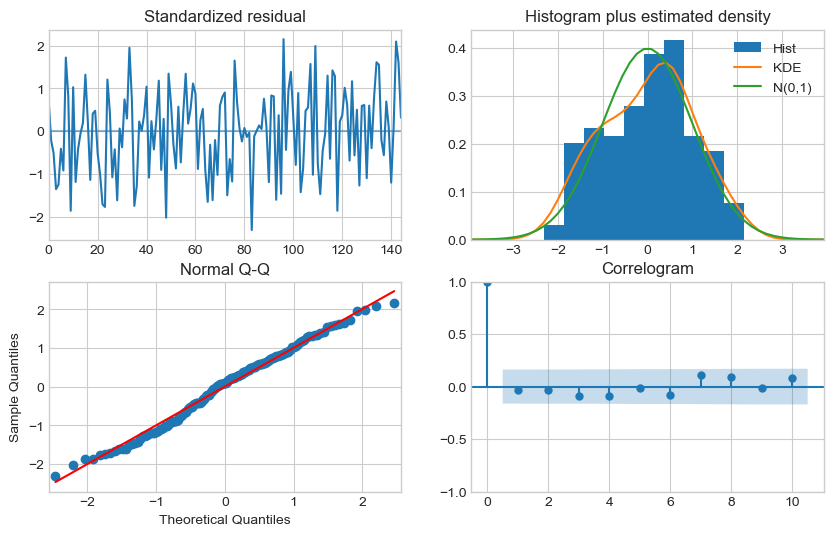

In [22]:
model.model_.plot_diagnostics(figsize=(10,6));

In [23]:
## ARIMA model setting using (3,1,1) with drift
model = ARIMA(order=(3, 1, 1), 
              with_intercept=True, 
              suppress_warnings=True)

model.fit(year)
print(model.summary())
# model.plot_diagnostics(figsize=(12, 8)) For model diagnostics. 

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  146
Model:               SARIMAX(3, 1, 1)   Log Likelihood                 125.709
Date:                Thu, 23 Apr 2026   AIC                           -239.417
Time:                        20:29:58   BIC                           -221.557
Sample:                             0   HQIC                          -232.160
                                - 146                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0277      0.016      1.762      0.078      -0.003       0.058
ar.L1         -1.0374      0.136     -7.655      0.000      -1.303      -0.772
ar.L2         -0.5308      0.105     -5.072      0.0

#### Initial SARIMA fitting for monthly data
The following is working with the full monthly data. Keep in mind that for time series data, the yearly J.D. data is not much different from running a 12 month smothing curve over each year. 

In [10]:
#Pulling the monthly data
years = Climate["Year"].astype(int)

month_df = Climate[['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']]

months = month_df.stack()
months.index = pd.to_datetime(
    [f"{y}-{m:02d}-01" for y in years for m in range(1, 13)]
)

months = pd.to_numeric(months, errors='coerce').dropna()

# Final holdout = last 10 years = 120 months
h = 120

y = months.copy()
y_train = y.iloc[:-h]
y_test  = y.iloc[-h:]

print("Full series length:", len(y))
print("Training length:", len(y_train))
print("Holdout length:", len(y_test))
print("Holdout start:", y_test.index[0], "Holdout end:", y_test.index[-1])


Full series length: 1740
Training length: 1620
Holdout length: 120
Holdout start: 2016-01-01 00:00:00 Holdout end: 2025-12-01 00:00:00


In [11]:
## Fuller Dickey test for differencing
adf_test = ADFTest(alpha=0.05)
p_val, should_diff = adf_test.should_diff(months)
print(f"P-value: {p_val}, Should difference: {should_diff}") 
# plot_acf(months) This plot definitely still needs differencing. 
# plot_pacf(months)

P-value: 0.01, Should difference: False


In [ ]:
## Checking auto arima
auto_model = AutoARIMA( # Note: p is the AR lags, q is the MA lags
    start_p=1, start_q=1, 
    max_p=2, max_q=2, # Defines the max q and p to test. 
    # Removed d=1 allowing autoARIMA to choose
    seasonal=True,
    m = 12, # modified this; we have 4 datapoints per year, we'd need to use the seasonal averages for this to work at m=4. 
    start_P = 0, start_Q = 0,
    max_P = 2, max_Q = 2,
    with_intercept=True,  # Suggesting "True"; even with seasonality, we have a warming trend. 
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

auto_model.fit(y_train)

print("Selected nonseasonal order:", auto_model.model_.order)
print("Selected seasonal order:", auto_model.model_.seasonal_order)
print("Training AIC:", auto_model.model_.aic())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=-2565.114, Time=1.30 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-2232.458, Time=0.34 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-2451.754, Time=0.91 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-2538.104, Time=1.51 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-2234.379, Time=0.43 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=-2563.286, Time=1.87 sec
 ARIMA(1,1,1)(0,0,1)[12] intercept   : AIC=-2563.253, Time=2.15 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : AIC=-2561.848, Time=2.22 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-2538.937, Time=0.42 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=-2451.922, Time=0.26 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : AIC=-2590.933, Time=2.56 sec
 ARIMA(2,1,1)(1,0,0)[12] intercept   : AIC=-2591.471, Time=3.21 sec
 ARIMA(2,1,1)(2,0,0)[12] intercept   : AIC=-2595.845, Time=6.87 sec
 ARIMA(2,1,1)(2,0,1)[12] intercept   : AIC=-2601.794, Time=9.08 sec
 ARIM

In [ ]:
best_order = auto_model.model_.order
best_seasonal_order = auto_model.model_.seasonal_order

final_model = ARIMA(
    order=best_order,
    seasonal_order=best_seasonal_order,
    with_intercept=True,
    suppress_warnings=True
)

final_model.fit(y_train)

print(final_model.summary())
final_model.plot_diagnostics(figsize=(12, 8));

# Forecast the last 10 years
y_pred = pd.Series(
    final_model.predict(n_periods=h),
    index=y_test.index
)

# Holdout metrics
holdout_mse = mean_squared_error(y_test, y_pred)
holdout_rmse = np.sqrt(holdout_mse)
holdout_mae = mean_absolute_error(y_test, y_pred)

print("Holdout MSE:", holdout_mse)
print("Holdout RMSE:", holdout_rmse)
print("Holdout MAE:", holdout_mae)

# Plot holdout forecast with a few years prior for comparison
plt.figure(figsize=(12, 6))
plt.plot(y_train.index[-60:], y_train.iloc[-60:], label="Last 5 years of training")
plt.plot(y_test.index, y_test, label="Actual holdout")
plt.plot(y_pred.index, y_pred, label="SARIMA forecast")
plt.title("SARIMA baseline: final 10-year holdout forecast")
plt.xlabel("Date")
plt.ylabel("Temperature anomaly")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Visualizing the time series data and models for yearly data.
forecast, conf = final_model.predict(n_periods = 120, return_conf_int = True)
fit = final_model.predict_in_sample(typ='levels')
year = as_series(Climate["J-D"])
year.index = pd.to_datetime(
    [f"{y}-01"
     for y in years]
)
month_range = pd.date_range(start=year.index[-10], periods=12*10, freq='MS')

plt.figure(figsize = (5,3))
plt.plot(year, linewidth = 1, label = "Original")
plt.plot(forecast, linestyle = "--", linewidth = .7, color = "coral", label = "Forecast")
plt.fill_between(month_range, conf[:,0], conf[:,1], color = 'skyblue', label = "Interval")
plt.plot(fit, linestyle = "--", linewidth = .5, color = "coral")
plt.title("Climate Anomaly SARIMA Forecast", fontsize = 10)
plt.ylabel("Deviation from baseline average", fontsize = 8)
plt.xlabel("Year")
plt.legend(fontsize = 8)
plt.show()

len(conf)

In [ ]:
# Time-series CV on training portion only for comparison with other models

tscv = TimeSeriesSplit(n_splits=5, test_size=24)
cv_errors = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(y_train), 1):
    fold_train = y_train.iloc[train_idx]
    fold_val = y_train.iloc[val_idx]

    fold_auto = AutoARIMA(
        start_p=1, start_q=1,
        max_p=2, max_q=2,
        seasonal=True,
        m=12,
        start_P=0, start_Q=0,
        max_P=2, max_Q=2,
        with_intercept=True,
        stepwise=True,
        trace=False,
        suppress_warnings=True
    )

    fold_auto.fit(fold_train)

    fold_model = ARIMA(
        order=fold_auto.model_.order,
        seasonal_order=fold_auto.model_.seasonal_order,
        with_intercept=True,
        suppress_warnings=True
    )

    fold_model.fit(fold_train)

    fold_pred = fold_model.predict(n_periods=len(fold_val))
    fold_mse = mean_squared_error(fold_val, fold_pred)
    cv_errors.append(float(fold_mse))

    print(f"Fold {fold} MSE: {fold_mse:.4f}")

print("CV errors:", cv_errors)
print("Mean CV MSE:", np.mean(cv_errors))

In [ ]:
# Save results for comparison notebook

results = {
    "model_name": "SARIMA",
    "cv_metric_name": "MSE",
    "cv_errors": list(cv_errors),
    "holdout_actual": y_test.tolist(),
    "holdout_pred": y_pred.tolist()
}

with open("sarima_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved sarima_results.json")